In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('D:\\csv files\\Sales.csv')

In [2]:
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no


In [3]:
df.isnull().sum()

Unnamed: 0     0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
high           0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   400 non-null    int64 
 1   CompPrice    400 non-null    int64 
 2   Income       400 non-null    int64 
 3   Advertising  400 non-null    int64 
 4   Population   400 non-null    int64 
 5   Price        400 non-null    int64 
 6   ShelveLoc    400 non-null    object
 7   Age          400 non-null    int64 
 8   Education    400 non-null    int64 
 9   Urban        400 non-null    object
 10  US           400 non-null    object
 11  high         400 non-null    object
dtypes: int64(8), object(4)
memory usage: 37.6+ KB


In [5]:
X_cont=df[df.columns[[1,2,3,4,5,7]]]
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss_x=ss.fit_transform(X_cont)
ss_x=pd.DataFrame(ss_x)
ss_x.columns=list(df.columns[[1,2,3,4,5,7]])
print(ss_x)

     CompPrice    Income  Advertising  Population     Price       Age
0     0.850455  0.155361     0.657177    0.075819  0.177823 -0.699782
1    -0.912484 -0.739060     1.409957   -0.032882 -1.386854  0.721723
2    -0.781896 -1.204159     0.506621    0.028262 -1.513719  0.350895
3    -0.520720  1.121336    -0.396715    1.366649 -0.794814  0.103677
4     1.046337 -0.166631    -0.547271    0.510625  0.516132 -0.947000
..         ...       ...          ...         ...       ...       ...
395   0.850455  1.407551     1.560513   -0.420131  0.516132 -1.256023
396   0.915749 -1.633482    -0.547271   -1.547909  0.177823  0.103677
397   2.417512 -1.526151     0.807733    0.700853  1.827078 -0.823391
398  -1.630719  0.370022     0.054953    0.130170 -0.879391 -0.205346
399   0.589279 -1.132606    -0.998939   -1.615848  0.177823 -0.267150

[400 rows x 6 columns]


In [6]:
#Converting column data text to numericals (works on numerical data only in DT)
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
df["ShelveLoc"]=LE.fit_transform(df["ShelveLoc"])
df["Urban"]=LE.fit_transform(df["Urban"])
df["US"]=LE.fit_transform(df["US"])
df["high"]=LE.fit_transform(df["high"])
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,0,42,17,1,1,1
1,2,111,48,16,260,83,1,65,10,1,1,1
2,3,113,35,10,269,80,2,59,12,1,1,1
3,4,117,100,4,466,97,2,55,14,1,1,0
4,5,141,64,3,340,128,0,38,13,1,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   400 non-null    int64
 1   CompPrice    400 non-null    int64
 2   Income       400 non-null    int64
 3   Advertising  400 non-null    int64
 4   Population   400 non-null    int64
 5   Price        400 non-null    int64
 6   ShelveLoc    400 non-null    int64
 7   Age          400 non-null    int64
 8   Education    400 non-null    int64
 9   Urban        400 non-null    int64
 10  US           400 non-null    int64
 11  high         400 non-null    int64
dtypes: int64(12)
memory usage: 37.6 KB


In [8]:
df_cat=df[df.columns[[6,8,9,10,11]]]
df_new=pd.concat([ss_x,df_cat], axis=1)
df_new

,CompPrice,Income,Advertising,Population,Price,Age,ShelveLoc,Education,Urban,US,high
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,0,17,1,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,1,10,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,2,12,1,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,2,14,1,1,0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,0,13,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
395,0.850455,1.407551,1.560513,-0.420131,0.516132,-1.256023,1,14,1,1,1
396,0.915749,-1.633482,-0.547271,-1.547909,0.177823,0.103677,2,11,0,1,0
397,2.417512,-1.526151,0.807733,0.700853,1.827078,-0.823391,2,18,1,1,0
398,-1.630719,0.370022,0.054953,0.130170,-0.879391,-0.205346,0,12,1,1,0


In [9]:
y=df_new["high"]
x=df_new.drop(df_new[['high']], axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3)
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion='gini')
DT.fit(x_train,y_train)
y_pred_train=DT.predict(x_train)
y_pred_test=DT.predict(x_test)
from sklearn.metrics import accuracy_score, log_loss
training_accuracy=accuracy_score(y_train,y_pred_train)
testing_accuracy=accuracy_score(y_test,y_pred_test)
training_loss=log_loss(y_train,y_pred_train)
testing_loss=log_loss(y_test,y_pred_test)
import numpy as np
print("Training Accuracy:",np.round(training_accuracy,2))
print("Testing Accuracy:",np.round(testing_accuracy,2))
print("Training Loss:", np.round(training_loss,2))
print("Testing Loss:",np.round(testing_loss,2))


Training Accuracy: 1.0
Testing Accuracy: 0.76
Training Loss: 0.0
Testing Loss: 8.71


In [10]:
#Shuffle Split
from sklearn.tree import DecisionTreeClassifier
import numpy as np
model=DecisionTreeClassifier(criterion='gini')
from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split=ShuffleSplit(n_splits=200, test_size=0.3, random_state=42)
cv_results=cross_validate(model,x,y,cv=shuffle_split,
                          scoring='accuracy',
                          return_train_score=True)
train_scores=cv_results['train_score']
test_scores=cv_results['test_score']
print("Cross Validation: train accuracy:",np.round(train_scores.mean(),2))
print("Cross Validation: test accuracy:", np.round(test_scores.mean(),2))


Cross Validation: train accuracy: 1.0
Cross Validation: test accuracy: 0.72


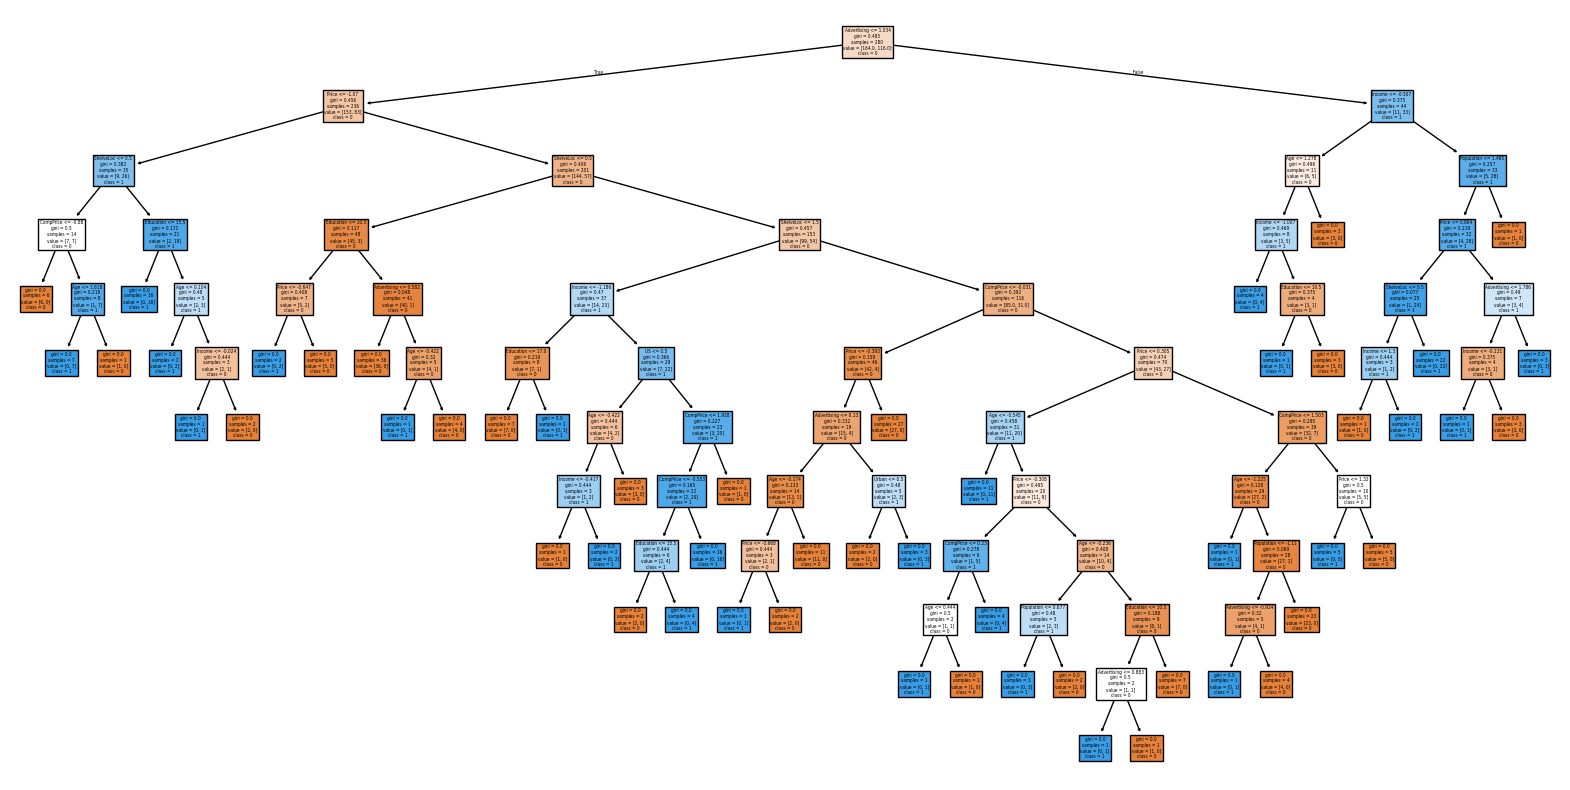

In [11]:
#visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(
    DT, 
    filled=True,
    feature_names=x.columns,
    class_names=['0','1']
)
plt.show()
          

In [12]:
#To count number of nodes and depth of tree
from sklearn.tree import DecisionTreeClassifier
n_nodes=DT.tree_.node_count
depth=DT.tree_.max_depth
print(f"Number of nodes:{n_nodes}")
print(f"Number of Depth of tree: {depth}")

Number of nodes:105
Number of Depth of tree: 11


In [13]:
#Ensemble methods 
#Bagging Classifier
from sklearn.ensemble import BaggingClassifier
bagging_model=BaggingClassifier(
    estimator=DecisionTreeClassifier(criterion='gini'),
    n_estimators=100,
    random_state=42,
    max_samples=0.6,
    max_features=0.7)
bagging_model.fit(x_train,y_train)
y_train_pred_bag=bagging_model.predict(x_train)
y_test_pred_bag=bagging_model.predict(x_test)
train_acc_bag=accuracy_score(y_train,y_train_pred_bag)
test_acc_bag=accuracy_score(y_test,y_test_pred_bag)
train_loss_bag=log_loss(y_train,y_train_pred_bag)
test_loss_bag=log_loss(y_test,y_test_pred_bag)
print("Bagging Training Accuracy:",np.round(train_acc_bag,2))
print("Bagging Test Accuracy:", np.round(test_acc_bag,2))
print("Bagging Training Loss:",np.round(train_loss_bag,2))
print("Bagging Testing Loss:", np.round(test_loss_bag,2))


Bagging Training Accuracy: 1.0
Bagging Test Accuracy: 0.82
Bagging Training Loss: 0.13
Bagging Testing Loss: 6.61


In [14]:
#Random Forest Example
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,
                                random_state=42,
                                max_samples=0.6,
                                max_features=0.7,
                                max_depth=10)
rf_model.fit(x_train,y_train)
y_train_pred_rf=rf_model.predict(x_train)
y_test_pred_rf=rf_model.predict(x_test)
train_pred_acc=accuracy_score(y_train,y_train_pred_rf)
test_pred_acc=accuracy_score(y_test,y_test_pred_rf)
train_loss_rf=log_loss(y_train,y_train_pred_rf)
test_loss_rf=log_loss(y_test,y_test_pred_rf)
print("Random Forest Training Accuracy:",np.round(train_pred_acc,2))
print("Random Forest Test Accuracy:", np.round(test_pred_acc,2))
print("Random Forest Train Loss:",np.round(train_loss_rf,2))
print("Random Forest Test Loss:", np.round(test_loss_rf,2))


Random Forest Training Accuracy: 0.99
Random Forest Test Accuracy: 0.83
Random Forest Train Loss: 0.26
Random Forest Test Loss: 6.01


In [15]:
#Grid Search CV
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators': [50,100,200],
    'max_samples' : [0.6,0.7,0.8]}
rf_model=RandomForestClassifier(
    random_state=42,
    max_depth=10)
grid_search=GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid, cv=5,
    scoring='accuracy')
grid_search.fit(x_train,y_train)
print("best hyperparameters:",grid_search.best_params_)
print("best score:",grid_search.best_score_)
best_rf_model=grid_search.best_estimator_
y_pred_test_best=best_rf_model.predict(x_test)
test_acc_best=accuracy_score(y_test,y_pred_test_best)
print("test accuracy best model:",test_acc_best)

best hyperparameters: {'max_samples': 0.6, 'n_estimators': 100}
best score: 0.775
test accuracy best model: 0.8


In [16]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(
    n_estimators=200,
    random_state=42,
    learning_rate=0.1)
gb_model.fit(x_train,y_train)
y_pred_train_gb=gb_model.predict(x_train)
y_pred_test_gb=gb_model.predict(x_test)
train_acc_gb=accuracy_score(y_train,y_pred_train_gb)
test_acc_gb=accuracy_score(y_test,y_pred_test_gb)
train_loss_gb=log_loss(y_train,y_pred_train_gb)
test_loss_gb=log_loss(y_test,y_pred_test_gb)
print("Gradient Boosting - Training Accuracy:",np.round(train_acc_gb,2))
print("Gradient Boosting - Testing Accuracy:",np.round(test_acc_gb,2))
print("Gradient Boosting - Training loss:",np.round(train_loss_gb,2))
print("Gradient Boosting - Testing loss:",np.round(test_loss_gb,2))


Gradient Boosting - Training Accuracy: 1.0
Gradient Boosting - Testing Accuracy: 0.86
Gradient Boosting - Training loss: 0.0
Gradient Boosting - Testing loss: 5.11


In [17]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators' : [50,100,200],
    'learning_rate' : [0.01, 0.1,1,10]
}
gb_model=GradientBoostingClassifier()
grid_search=GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy')
grid_search.fit(x_train,y_train)
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:",grid_search.best_score_)
best_gb_model=grid_search.best_estimator_
y_pred_test_best=best_gb_model.predict(x_test)
test_accuracy_best=accuracy_score(y_test,y_pred_test_best)
print("Test Accuracy:",test_accuracy_best)


Best hyperparameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best score: 0.7964285714285715
Test Accuracy: 0.8833333333333333


In [18]:
#Adaboost 
from sklearn.ensemble import AdaBoostClassifier
ab_model=AdaBoostClassifier()
ab_model.fit(x_train,y_train)
y_pred_train_ab=ab_model.predict(x_train)
y_pred_test_ab=ab_model.predict(x_test)
training_accuracy_ab=accuracy_score(y_train,y_pred_train_ab)
testing_accuracy_ab=accuracy_score(y_test,y_pred_test_ab)
training_loss_ab=log_loss(y_train,y_pred_train_ab)
testing_loss_ab=log_loss(y_test,y_pred_test_ab)
print("Adaboost-Training Accuracy:",np.round(training_accuracy_ab,2))
print("Adaboost-Testing Accuracy:",np.round(testing_accuracy_ab,2))
print("Adaboost-Training Loss:", np.round(training_loss_ab,2))
print("Adaboost-Testing Loss:", np.round(testing_loss_ab,2))


Adaboost-Training Accuracy: 0.94
Adaboost-Testing Accuracy: 0.88
Adaboost-Training Loss: 2.32
Adaboost-Testing Loss: 4.21


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
param_grid={
    'n_estimators' : [50,100,200],
    'learning_rate' : [0.01,0.1,1,10]}
ab_model=AdaBoostClassifier()
grid_search=GridSearchCV(
    estimator=ab_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy')
grid_search.fit(x_train,y_train)
print("Best hyperparameters:",grid_search.best_params_)
print("Best Score:",grid_search.best_estimator_)
best_ab_model=grid_search.best_estimator_
y_pred_test_best=best_ab_model.predict(x_test)
test_accuracy_best=accuracy_score(y_test,y_pred_test_best)
print("Test Accuracy best model:",test_accuracy_best)

Best hyperparameters: {'learning_rate': 1, 'n_estimators': 100}
Best Score: AdaBoostClassifier(learning_rate=1, n_estimators=100)
Test Accuracy best model: 0.9166666666666666


In [20]:
#XG BOOST Model
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss
xgb_model=xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42)
xgb_model.fit(x_train,y_train)
y_pred_train_xgb=xgb_model.predict(x_train)
y_pred_test_xgb=xgb_model.predict(x_test)
training_accuracy_xgb=accuracy_score(y_train,y_pred_train_xgb)
testing_accuracy_xgb=accuracy_score(y_test,y_pred_test_xgb)
training_loss_xgb=log_loss(y_train,y_pred_train_xgb)
testing_loss_xgb=log_loss(y_test,y_pred_test_xgb)
print("XGBOOST- Training Accuracy:",np.round(training_accuracy_xgb,2))
print("XGBOOST- Testing Accuracy:",np.round(testing_accuracy_xgb,2))
print("XGBOOST - Training Loss:", np.round(training_loss_xgb,2))
print("XGBOOST - Testing Loss:", np.round(testing_loss_xgb,2))


XGBOOST- Training Accuracy: 1.0
XGBOOST- Testing Accuracy: 0.87
XGBOOST - Training Loss: 0.0
XGBOOST - Testing Loss: 4.81


In [21]:
#Apply Grid Search
from sklearn.model_selection import GridSearchCV
param_grid_xgb={
    'n_estimators' : [50,100,200],
    'learning_rate' : [0.01,0.1,0.2],
    'gamma' : [0,0.1,0.5],
    'reg_lambda' : [0,0.1,1]
}
xgb_model=xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42)
grid_search_xgb=GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5, 
    scoring='accuracy')
grid_search_xgb.fit(x_train,y_train)
print("XGBoost - Hyperparameters", grid_search_xgb.best_params_)
print("XGBoost - Best score:",grid_search_xgb.best_score_)
best_xgb_model=grid_search_xgb.best_estimator_
y_pred_test_best_xgb=best_xgb_model.predict(x_test)
test_accuracy_best_xgb=accuracy_score(y_test,y_pred_test_best_xgb)
print("XGB Accuracy:", test_accuracy_best_xgb)


XGBoost - Hyperparameters {'gamma': 0, 'learning_rate': 0.1, 'n_estimators': 200, 'reg_lambda': 0}
XGBoost - Best score: 0.825
XGB Accuracy: 0.8666666666666667


In [22]:
#Rotation Forest
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
rotation_rf_pipeline=Pipeline([
    ('pca', PCA(n_components=x_train.shape[1])),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42))
])
rotation_rf_pipeline.fit(x_train,y_train)
y_pred_train=rotation_rf_pipeline.predict(x_train)
y_pred_test=rotation_rf_pipeline.predict(x_test)
train_accuracy=accuracy_score(y_train,y_pred_train)
test_accuracy=accuracy_score(y_test,y_pred_test)
print(f"PCA+ Rotation Forest_train Accuracy:,{train_accuracy:.2f}")
print(f"PCA+Random Forest test Accuracry:,{test_accuracy:.2f}")


PCA+ Rotation Forest_train Accuracy:,1.00
PCA+Random Forest test Accuracry:,0.85


In [23]:
import pandas as pd
df=pd.read_csv("D:\\csv files\\tour_packages_lightgbm.csv")
df.head

<bound method NDFrame.head of    destination  duration_days  num_people  hotel_star_rating transport_type  \
0        Dubai             14           1                  5         Flight   
1       London              9           2                  4          Train   
2         Bali             11           2                  3            Bus   
3       London             10           4                  5          Train   
4       London             14           2                  3            Bus   
..         ...            ...         ...                ...            ...   
95        Bali              7           3                  3          Train   
96      London              3           1                  3         Flight   
97         Goa             10           1                  5            Bus   
98         Goa              3           3                  4         Flight   
99       Paris             13           3                  5          Train   

        season guide_

In [34]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
df_encoded=pd.get_dummies(
    df,
    columns=['destination', 'transport_type','season','guide_included'],
    drop_first=True)
x=df_encoded.drop("price",axis=1)
y=df_encoded["price"]
x_train,x_test,y_train,x_test=train_test_split(x,y, 
                                                test_size=0.02,
                                               random_state=42)
train_data=lgb.Dataset(x_train, label=y_train)
valid_data=lgb.Dataset(x_test, 
                       label=y_test, 
                       reference=train_data)
params={
    'objective' : 'regression',
    'metric' : 'rmse',
    'learning_rate' : 0.05,
    'num_leaves' : 31,
    'verbose': -1
}
model=lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[valid_data],
    callbacks=[
        early_stopping(stopping_rounds=10),
               log_evaluation(period=0)
    ]
)
y_pred=model.predict(x_test)
rmse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
evaluation_results={
    "RMSE" : rmse,
    "MAE" : mae,
    "R2" : r2
}
evaluation_results

KeyError: "None of [Index(['destination', 'transport_type', 'season', 'guide_included'], dtype='object')] are in the [columns]"

In [ ]:
#Dimensional Reduction Techniques

In [26]:
import pandas as pd
df=pd.read_csv("D:\\csv files\\breast-cancer-wisconsin-data.csv")

In [27]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
y=df["diagnosis"]
x=df.iloc[:,2: ]
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [32]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss_x=ss.fit_transform(x)
ss_x=pd.Dataframe(ss_x)
ss_x.head()

AttributeError: module 'pandas' has no attribute 'Dataframe'

In [35]:
from sklearn.decomposition import PCA
pca=PCA()
pc_x=pca.fit_transform(ss_x)
pc_x=pd.Dataframe(pc_x)
pc_x.head()

AttributeError: module 'pandas' has no attribute 'Dataframe'

In [ ]:
pc_x.var()

In [ ]:
df